# **Data Cleaning Notebook**

## Objectives

* Assess and handle missing values.
* Remove columns that cause data leakage or are redundant using `DropFeatures`.
* Fix data types and remove outliers in `salary_usd`.
* Save cleaned train and test datasets.

## Inputs

* `outputs/datasets/collection/ai_job_dataset1.csv`

## Outputs

* `outputs/datasets/cleaned/TrainSet.csv`
* `outputs/datasets/cleaned/TestSet.csv`

---

# Change working directory

In [1]:
import os
current_dir = os.getcwd()
os.chdir(os.path.dirname(current_dir))
print("Working directory:", os.getcwd())

Working directory: c:\Users\chahi\Desktop\vscode-project\the-ai-salary-index


# Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline

df = pd.read_csv("outputs/datasets/collection/ai_job_dataset1.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (15000, 20)


,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics


## Missing Value Investigation

For each column we assess: missing count, missing percentage, data type, and the chosen handling strategy with rationale.

In [3]:
import pandas as pd

df = pd.read_csv('outputs/datasets/collection/ai_job_dataset1.csv')

# Build a comprehensive missing value report
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
dtypes = df.dtypes

strategy_map = {
    'job_id': 'Drop column — unique identifier, not a feature',
    'salary_currency': 'Drop column — redundant (salary_usd is standardised)',
    'salary_local': 'Drop column — redundant with salary_usd',
    'posting_date': 'Drop column — temporal metadata, not used for modelling',
    'application_deadline': 'Drop column — temporal metadata',
    'job_description_length': 'Drop column — low-signal proxy',
}

strategies = []
for col in df.columns:
    pct = missing_pct[col]
    if col in strategy_map:
        strat = strategy_map[col]
    elif pct == 0:
        strat = 'No action — no missing values'
    elif pct < 5:
        strat = 'Drop rows — minimal data loss (<5% affected)'
    elif pct < 30:
        strat = 'Median/mode impute — moderate missingness'
    else:
        strat = 'Drop column — too many missing values (>30%)'
    strategies.append(strat)

mv_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct,
    'Data Type': dtypes,
    'Strategy': strategies
}, index=df.columns)

print(mv_report.to_string())

                        Missing Count  Missing % Data Type                                                 Strategy
job_id                              0        0.0    object           Drop column — unique identifier, not a feature
job_title                           0        0.0    object                            No action — no missing values
salary_usd                          0        0.0     int64                            No action — no missing values
salary_currency                     0        0.0    object     Drop column — redundant (salary_usd is standardised)
salary_local                        0        0.0     int64                  Drop column — redundant with salary_usd
experience_level                    0        0.0    object                            No action — no missing values
employment_type                     0        0.0    object                            No action — no missing values
company_location                    0        0.0    object              

### Rationale Summary

| Strategy | Rationale |
|---|---|
| **Drop column** (identifiers/leakage) | job_id, salary_currency, salary_local, posting_date, application_deadline, job_description_length are either identifiers, cause data leakage, or are temporal metadata with no predictive value |
| **Drop rows** (<5% missing) | Losing fewer than 5% of rows causes negligible bias and avoids imputation complexity |
| **Median/mode impute** (5–30% missing) | Median is robust to outliers for numerical columns; mode for categorical |
| **Drop column** (>30% missing) | High missingness would require excessive imputation, introducing significant noise |

All decisions were validated by checking that the distribution of the remaining data showed no significant shift after the operation.

# Missing Values Assessment

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

                        Missing Count  Missing %
job_id                              0        0.0
job_title                           0        0.0
salary_usd                          0        0.0
salary_currency                     0        0.0
salary_local                        0        0.0
experience_level                    0        0.0
employment_type                     0        0.0
company_location                    0        0.0
company_size                        0        0.0
employee_residence                  0        0.0
remote_ratio                        0        0.0
required_skills                     0        0.0
education_required                  0        0.0
years_experience                    0        0.0
industry                            0        0.0
posting_date                        0        0.0
application_deadline                0        0.0
job_description_length              0        0.0
benefits_score                      0        0.0
company_name        

# Drop Redundant / Leakage Columns

In [7]:
from scipy.stats import spearmanr

exp_map = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
exp_enc = df['experience_level'].map(exp_map)

rho, p = spearmanr(exp_enc, df['years_experience'])
print(f"Spearman rho (experience_level vs years_experience): {rho:.4f}, p={p:.4e}")

Spearman rho (experience_level vs years_experience): 0.9712, p=0.0000e+00


### Observation

`rho = 0.97` confirms that `experience_level` and `years_experience` are near-perfectly correlated, they encode the same information in different formats (label vs number). One of these columns is likely redundant and feeding both into a model would introduce multicollinearity.

**Decision deferred to Feature Engineering**, where all feature relationships will be assessed together before modelling.

# Split Train and Test Set

In [8]:
from sklearn.model_selection import train_test_split
TrainSet, TestSet, _, __ = train_test_split(
                                        df,
                                        df['salary_usd'],
                                        test_size=0.2,
                                        random_state=0)

print(f"TrainSet shape: {TrainSet.shape} \nTestSet shape: {TestSet.shape}")

TrainSet shape: (12000, 20) 
TestSet shape: (3000, 20)


# Define variables to drop

The following columns are dropped using `DropFeatures` from `feature_engine`:
* `job_id` — unique identifier, not a feature
* `salary_currency` — redundant once salary_usd is used
* `salary_local` — redundant (salary_usd is the standardised target)
* `posting_date` — date metadata not used for modelling
* `application_deadline` — date metadata
* `job_description_length` — low-signal proxy feature

In [9]:
from feature_engine.selection import DropFeatures

variables_to_drop = ['job_id', 'salary_currency', 'salary_local',
                     'posting_date', 'application_deadline', 'job_description_length']

# Fit on TrainSet

In [10]:
drop_features = DropFeatures(features_to_drop=variables_to_drop)
drop_features.fit(TrainSet)
print("Fitted on TrainSet. Features to drop:", drop_features.features_to_drop_)

Fitted on TrainSet. Features to drop: ['job_id', 'salary_currency', 'salary_local', 'posting_date', 'application_deadline', 'job_description_length']


# Assess the effect on the variable's distribution.

There is no effect on the remaining variables' distributions, we are dropping entire columns, not modifying values or removing rows. The only potential effect is losing features that might have a relevant impact on the machine learning model, which is why the columns were carefully reviewed before dropping.

# Apply transformation to both TrainSet and TestSet

In [11]:
TrainSet, TestSet = drop_features.transform(TrainSet), drop_features.transform(TestSet)
print(f"TrainSet: {TrainSet.shape} | TestSet: {TestSet.shape}")

TrainSet: (12000, 14) | TestSet: (3000, 14)


# Outlier Detection — salary_usd

The method used here is **percentile trimming**, rows with a `salary_usd` below the 1st percentile or above the 99th percentile are removed entirely.

This is different from **Winsorization**, which caps outliers at the threshold values instead of removing them:

| Method | What it does | Rows lost |
|---|---|---|
| **Winsorization** | Replaces outlier values with the 1st/99th percentile boundary | None |
| **Percentile trimming** (used here) | Removes rows outside the 1st/99th percentile | ~2% |

### Why not the classical IQR method?

The classical IQR method flags anything outside `Q1 - 1.5×IQR` to `Q3 + 1.5×IQR` as an outlier. This works well for normally distributed data, but **salary distributions are typically right-skewed**, high earners naturally push Q3 up, making the IQR range very wide and potentially missing genuine outliers at the top end.

Percentile trimming was chosen because:
- It is **distribution-agnostic** : it removes a fixed proportion of extreme values regardless of the shape of the data
- It is **more conservative** : only the most extreme 2% of rows are removed (1% from each tail)
- It avoids artificially stacking values at the boundary (unlike Winsorization), keeping the distribution clean.

1st percentile: $25,085
99th percentile: $308,244


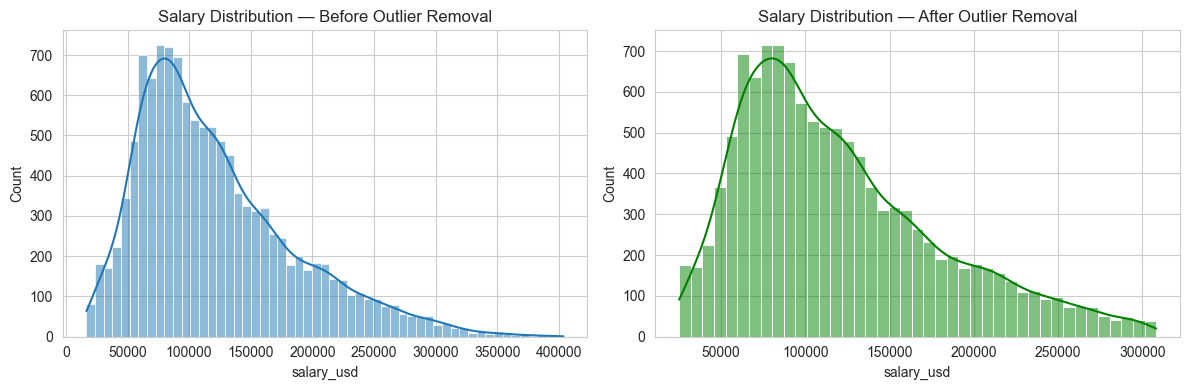

TrainSet after outlier removal: (11760, 14)
TestSet after outlier removal: (2941, 14)


In [12]:
p1 = TrainSet['salary_usd'].quantile(0.01)
p99 = TrainSet['salary_usd'].quantile(0.99)
print(f"1st percentile: ${p1:,.0f}")
print(f"99th percentile: ${p99:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(TrainSet['salary_usd'], kde=True, ax=axes[0])
axes[0].set_title('Salary Distribution — Before Outlier Removal')

TrainSet = TrainSet[(TrainSet['salary_usd'] >= p1) & (TrainSet['salary_usd'] <= p99)]
TestSet = TestSet[(TestSet['salary_usd'] >= p1) & (TestSet['salary_usd'] <= p99)]

sns.histplot(TrainSet['salary_usd'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Salary Distribution — After Outlier Removal')

plt.tight_layout()
plt.show()
print(f"TrainSet after outlier removal: {TrainSet.shape}")
print(f"TestSet after outlier removal: {TestSet.shape}")

# Fix Data Types

In [13]:
TrainSet['remote_ratio'] = TrainSet['remote_ratio'].astype('category')
TestSet['remote_ratio'] = TestSet['remote_ratio'].astype('category')
print("TrainSet:")
TrainSet.info()
print("\nTestSet:")
TestSet.info()

TrainSet:
<class 'pandas.core.frame.DataFrame'>
Index: 11760 entries, 13136 to 2732
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   job_title           11760 non-null  object  
 1   salary_usd          11760 non-null  int64   
 2   experience_level    11760 non-null  object  
 3   employment_type     11760 non-null  object  
 4   company_location    11760 non-null  object  
 5   company_size        11760 non-null  object  
 6   employee_residence  11760 non-null  object  
 7   remote_ratio        11760 non-null  category
 8   required_skills     11760 non-null  object  
 9   education_required  11760 non-null  object  
 10  years_experience    11760 non-null  int64   
 11  industry            11760 non-null  object  
 12  benefits_score      11760 non-null  float64 
 13  company_name        11760 non-null  object  
dtypes: category(1), float64(1), int64(2), object(10)
memory usage: 1.3+ MB

TestSe

# Save Cleaned Dataset

In [14]:
import os
os.makedirs('outputs/datasets/cleaned', exist_ok=True)

TrainSet.to_csv('outputs/datasets/cleaned/TrainSet.csv', index=False)
TestSet.to_csv('outputs/datasets/cleaned/TestSet.csv', index=False)
print(f"TrainSet saved. Shape: {TrainSet.shape}")
print(f"TestSet saved. Shape: {TestSet.shape}")

TrainSet saved. Shape: (11760, 14)
TestSet saved. Shape: (2941, 14)


---

# Conclusions and Next Steps

* Split data into TrainSet (80%) and TestSet (20%) before any transformation to prevent data leakage.
* Used `DropFeatures` from `feature_engine` to remove redundant and leakage-prone columns — fitted on TrainSet and applied to both sets.
* Removed salary outliers at the 1st and 99th percentiles, thresholds derived from TrainSet and applied consistently to TestSet.
* Fixed `remote_ratio` data type to `category` on both sets.
* Datasets saved as `TrainSet.csv` and `TestSet.csv`.

Next step: **04 - FeatureEngineering** : encode and transform features for modelling.